In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import invwishart
import jax
import jax.numpy as jnp
from jax import vmap, random

# --------------------------------------------------------
# 0. Setting up the environment and importing necessary libraries
# --------------------------------------------------------
# This script implements the algorithm by Rubio-Ramirez, Waggoner and Zha (2010) on Uhlig's (2005) data.
# Note: Ensure 'uhligdata.xls' is in the current working directory.
# JAX is utilized for performance optimization during the QR decomposition and null space mapping phases.

# ==========================================
# 1. DATA PREPARATION
# ==========================================

# Load dataset and drop NA values to ensure a balanced panel.
filepath = 'uhligdata.xls'
df = pd.read_excel(filepath).dropna()

# --------------------------------------------------------
# Log-transformations
# --------------------------------------------------------
# We apply a log-transformation (* 100) to non-stationary level variables to stabilize variance 
# and interpret shocks as percentage deviations.
# Following Uhlig (2005) and standard macroeconomic convention, the federal funds rate (FEDFUNDS) 
# is strictly EXCLUDED from this transformation, as it is already expressed in percentage terms.
cols_to_log = ['GDPC1', 'GDPDEF', 'CPRINDEX', 'BOGNONBR', 'TOTRESNS']
for col in cols_to_log:
    df[col] = np.log(df[col]) * 100

# Define the variable ordering according to the baseline model and extract the raw array.
ordered_cols = ['GDPC1', 'GDPDEF', 'CPRINDEX', 'FEDFUNDS', 'BOGNONBR', 'TOTRESNS']
Y_raw = df[ordered_cols].values

# --------------------------------------------------------
# Constructing the VAR Design Matrix (X) and Dependent Variable (Y)
# --------------------------------------------------------
# We set the lag order p = 12 (standard for monthly macroeconomic data).
p = 12
T_raw, m = Y_raw.shape
T = T_raw - p  # Effective sample size after discarding initial observations for lags

# Define the dependent variable matrix (Y), dropping the first p periods.
Y = Y_raw[p:]

# Pre-allocate and populate the design matrix (X) with lagged values.
X = np.zeros((T, m * p))
for i in range(p):
    X[:, i*m : (i+1)*m] = Y_raw[p - i - 1 : T_raw - i - 1]

# Append a column of ones to the right side of X to account for the VAR intercept.
X = np.hstack([X, np.ones((T, 1))])

In [10]:
# ==========================================
# 2. ESTIMATING THE REDUCED-FORM VAR (OLS)
# ==========================================
# We estimate the reduced-form VAR using standard ordinary least squares (OLS).
# X is the design matrix (lags + constant), Y is the dependent variable matrix.
inv_XX = np.linalg.inv(X.T @ X)
B_ols = inv_XX @ X.T @ Y
U = Y - X @ B_ols

# Compute the unbiased covariance matrix of the residuals (Sigma_ols).
df_residuals = T - m * p - 1
Sigma_ols = (U.T @ U) / df_residuals

# ==========================================
# 3. VECTORIZED RWZ (2010) ALGORITHM WITH JAX
# ==========================================
# This section implements the independent Haar measure draws required for sign-restricted 
# SVAR models (Algorithm 2 in Rubio-Ramirez, Waggoner, and Zha, 2010).
# We define a function to generate valid orthogonal matrices and vectorize it using JAX 
# to draw thousands of them simultaneously on the CPU/GPU.


def generate_Q_rwz(key, n):
    """
    Generates a single orthogonal matrix Q drawn uniformly from the Haar measure O(n).
    This follows Theorem 4 (p. 677) of RWZ (2010).
    """
    # 1. Draw an n x n matrix from the standard normal distribution.
    # This provides the independent Gaussian basis required for the uniform mapping.
    X_draw = random.normal(key, (n, n))
    
    # 2. Perform QR decomposition.
    # Q_raw is orthogonal, R is upper triangular.
    Q_raw, R = jnp.linalg.qr(X_draw)
    
    # 3. Normalization step (Crucial for Haar measure properties).
    # The QR decomposition is not strictly unique. To ensure that the resulting matrix Q 
    # is uniformly distributed over the orthogonal group O(n) according to the Haar measure,
    # we must normalize the columns of Q_raw by the signs of the diagonal elements of R.
    diag_R = jnp.diag(R)
    signs = jnp.sign(diag_R)
    
    # In the extremely rare event of a perfect 0, default to 1.0 to avoid zeroing out a column.
    signs = jnp.where(signs == 0, 1.0, signs)
    
    # The final normalized orthogonal matrix Q.
    Q_normalized = Q_raw * signs
    
    return Q_normalized

# Vectorize the function using jax.vmap for massive parallelization.
# in_axes=(0, None) means the first argument (key) is batched, and the second (n) is constant.
vmap_generate_Q = vmap(generate_Q_rwz, in_axes=(0, None))

# Initialize the JAX pseudo-random number generator (PRNG) for reproducibility.
seed = 42
key = random.PRNGKey(seed)

# Set matrix dimensions and the number of independent draws.
n_vars = m 
num_draws = 10000

# Split the master key into a batch of keys for parallel execution.
keys = random.split(key, num_draws)

# Execute the vectorized function to instantly generate the batch of orthogonal matrices.
# Q_batch will have the shape (num_draws, n_vars, n_vars), i.e., (10000, 6, 6) for our case, and it stores all the independent draws of Q matrices.
Q_batch = vmap_generate_Q(keys, n_vars)

print(f"Shape of Q_batch: {Q_batch.shape}")
print("If the shape is (10000, 6, 6), the RWZ engine is successfully running!")

Shape of Q_batch: (10000, 6, 6)
If the shape is (10000, 6, 6), the RWZ engine is successfully running!


In [11]:
# ==========================================
# 4. COMPUTE BASE IRFS AND APPLY JAX TENSOR MULTIPLICATION
# ==========================================
# In this part of the code, we want to see what happens in identification terms when we have inequality restrictions on the IRFs. 
# We will compute the base IRFs and then apply the batch of orthogonal matrices to obtain structural IRFs.

def compute_companion_matrix(B, m, p):
    """
    Constructs the companion matrix (F) for the VAR(p) process.
    
    CONNECTION TO RWZ (2010): 
    While RWZ (2010) does not explicitly define this standard time-series object, 
    it is the mathematical engine required to compute the reduced-form moving 
    average matrices (Phi_h). In the RWZ framework, these Phi_h matrices are 
    subsequently multiplied by the structural impact matrix to produce the 
    structural IRFs (L_h) upon which the sign restrictions are evaluated.
    
    Note: This matrix contains REDUCED-FORM coefficients, NOT the structural A_+.
    """
    # Exclude the constant term (last row of B) and transpose.
    # This yields the (m x m*p) upper block containing the B_1 ... B_p matrices.
    B_lags = B[:-1, :].T  
    
    # Initialize the huge (m*p x m*p) companion matrix F with zeros.
    companion = np.zeros((m*p, m*p))
    
    # Insert the reduced-form VAR coefficients into the top block.
    companion[:m, :] = B_lags
    
    # Create the identity matrix blocks shifting the lagged states 
    # (the 'I' matrices in the lower-left sub-blocks).
    if p > 1:
        companion[m:, :-m] = np.eye(m*(p-1))
        
    return companion

# The next function computes the orthogonalized impulse response functions (IRFs) using the Cholesky decomposition of the covariance matrix Sigma.
# The code uses that contempraneous impulse response is given by the Cholesky factor of Sigma, and the dynamic responses are computed using the powers of the companion matrix.
def get_base_irfs(B, Sigma, m, p, horizon = 60):
    """Computes the orthogonalized IRFs using Cholesky decomposition."""
    C = np.linalg.cholesky(Sigma)
    comp = compute_companion_matrix(B, m, p)
    
    # The next line initializes the base IRF array with zeros. The shape is (horizon, m, m), where:
    # - horizon: number of periods to compute the IRFs for (e.g., 60 months)
    # - m: number of variables in the VAR
    # - m: number of shocks (same as number of variables for a square system).
    # Therefore, np.zeros((horizon, m, m)) is a 3D NumPy array with the size (horizon, m, m) and is used to store the computed IRFs for each period.
    # comp_power is initialized as the identity matrix of size (m*p x m*p) to represent the initial state of the system before any shocks are applied.
    irf_base = np.zeros((horizon, m, m))
    comp_power = np.eye(m * p)
    
    for h in range(horizon):
        # The top-left m x m block in the powered companion matrix, to be multiplied by the Cholesky factor C
        irf_base[h, :, :] = comp_power[:m, :m] @ C
        comp_power = comp @ comp_power
        
    return irf_base

# Calculate the base IRF for the horizon of 60 months
horizon = 60
irf_base_ols = get_base_irfs(B_ols, Sigma_ols, m, p, horizon)

# Convert to JAX array for tensor operations
irf_base_jnp = jnp.array(irf_base_ols)

# The MAGIC of JAX: Einstein summation
# irf_base_jnp shape: (horizon = 60, variables = 6, shocks = 6) -> hvs. This is a 3D tensor representing the base IRFs for each variable and shock over the specified horizon.
# Q_batch shape: (draws = 10000, shocks_in = 6, shocks_out = 6) -> qsk. This is another 3D tensor representing the batch of orthogonal matrices drawn from the Haar measure.
# Result shape: (draws = 10000, horizon = 60, variables = 6, shocks = 6) -> qhvk. This is a 4D tensor that will store the structural IRFs for all draws, periods, variables, and shocks.
# This mathematically performs: structural_IRF_h = base_IRF_h @ Q for all 10,000 draws instantly.
# struct_irfs will have the shape (10000, 60, 6, 6), where:
# - 10000: number of independent draws of orthogonal matrices (Q)
# - 60: number of periods in the IRF horizon
# - 6: number of variables in the VAR
# - 6: number of shocks (same as number of variables for a square system)
# and it stores the structural IRFs for all rotation matrices, periods, variables, and shocks in a single 4D tensor.
struct_irfs = jnp.einsum('hvs,qsk->qhvk', irf_base_jnp, Q_batch)


# ==========================================
# 5. APPLYING THE SIGN RESTRICTION MASK
# ==========================================
# NOTE: According to RWZ (2010), no SVAR with indequality (i.e. sign) restrictions can be identified, either globally or locally. 
# In this code, therefore, we are unable to find ONE model that satisfies the restrictions for all draws. 
# Instead, we will count how many draws satisfy the restrictions and report that number. 
# We have applied the rotaion matrices of the previous step to the base IRFs, and now we will check which of the 10,000 
# draws satisfy the sign restrictions for a contractionary monetary policy shock.

# # Uhlig's Variables Order: 
# 0: GDPC1, 1: GDPDEF (Prices), 2: CPRINDEX (Commodities)
# 3: FEDFUNDS (Interest Rate), 4: BOGNONBR (NBR), 5: TOTRESNS (Total Reserves)

irs = 6  # Restriction horizon: months 0 to 5 (6 periods)

# We apply pure sign restrictions to identify a contractionary Monetary Policy (MP) shock.
# Conditions for the MP shock: GDPDEF <= 0, CPRINDEX <= 0, FEDFUNDS >= 0, BOGNONBR <= 0.
# NOTE: We do NOT assume that the monetary policy shock is in a specific column. The JAX tensor operations 
# implicitly evaluate ALL shock columns simultaneously across all draws.

cond_prices    = struct_irfs[:, :irs, 1, :] <= 0
cond_commodity = struct_irfs[:, :irs, 2, :] <= 0
cond_fedfunds  = struct_irfs[:, :irs, 3, :] >= 0
cond_nbr       = struct_irfs[:, :irs, 4, :] <= 0

# Combine conditions (logical AND across all economic restrictions)
# This line creates a boolean mask checking if all required conditions are satisfied 
# simultaneously. Shape of combined_cond: (10000 draws, 6 periods, 6 shocks).
combined_cond = cond_prices & cond_commodity & cond_fedfunds & cond_nbr

# We require the conditions to hold for ALL periods (h = 0..5) for a given shock column.
# The command jnp.all means that we are checking if the conditions are satisfied for every period in the horizon for each shock column.
# jnp.all over axis 1 (horizon) -> shape: (10000 draws, 6 shocks).
# This reduces the horizon dimension by ensuring the conditions hold continuously. 
# The result is a boolean array indicating whether each shock column meets the criteria.
valid_shocks_across_horizon = jnp.all(combined_cond, axis=1)

# Now, does a draw have AT LEAST ONE shock column that perfectly satisfies the restrictions?
# jnp.any over axis 1 (shocks) -> shape: (10000 draws,).
# This checks if there is at least one valid shock column within the 6 possibilities. 
# If true, the entire rotation matrix (draw) is flagged as valid.
valid_draws_mask = jnp.any(valid_shocks_across_horizon, axis = 1)

# Count how many successful draws we have.
# This sums the boolean array valid_draws_mask (where True = 1, False = 0).
# The result, num_valid, represents the total number of valid rotation matrices found.
num_valid = jnp.sum(valid_draws_mask)

print(f"Number of valid rotation matrices found out of {num_draws}: {num_valid}")

Number of valid rotation matrices found out of 10000: 2357


Starting Bayesian RWZ algorithm. Targeting 1000 valid structural IRFs...
Accepted 100 / 1000 draws...
Accepted 200 / 1000 draws...
Accepted 300 / 1000 draws...
Accepted 400 / 1000 draws...
Accepted 500 / 1000 draws...
Accepted 600 / 1000 draws...
Accepted 700 / 1000 draws...
Accepted 800 / 1000 draws...
Accepted 900 / 1000 draws...
Accepted 1000 / 1000 draws...
Done! We have successfully harvested 1000 Bayesian structural IRFs using RWZ (2010).


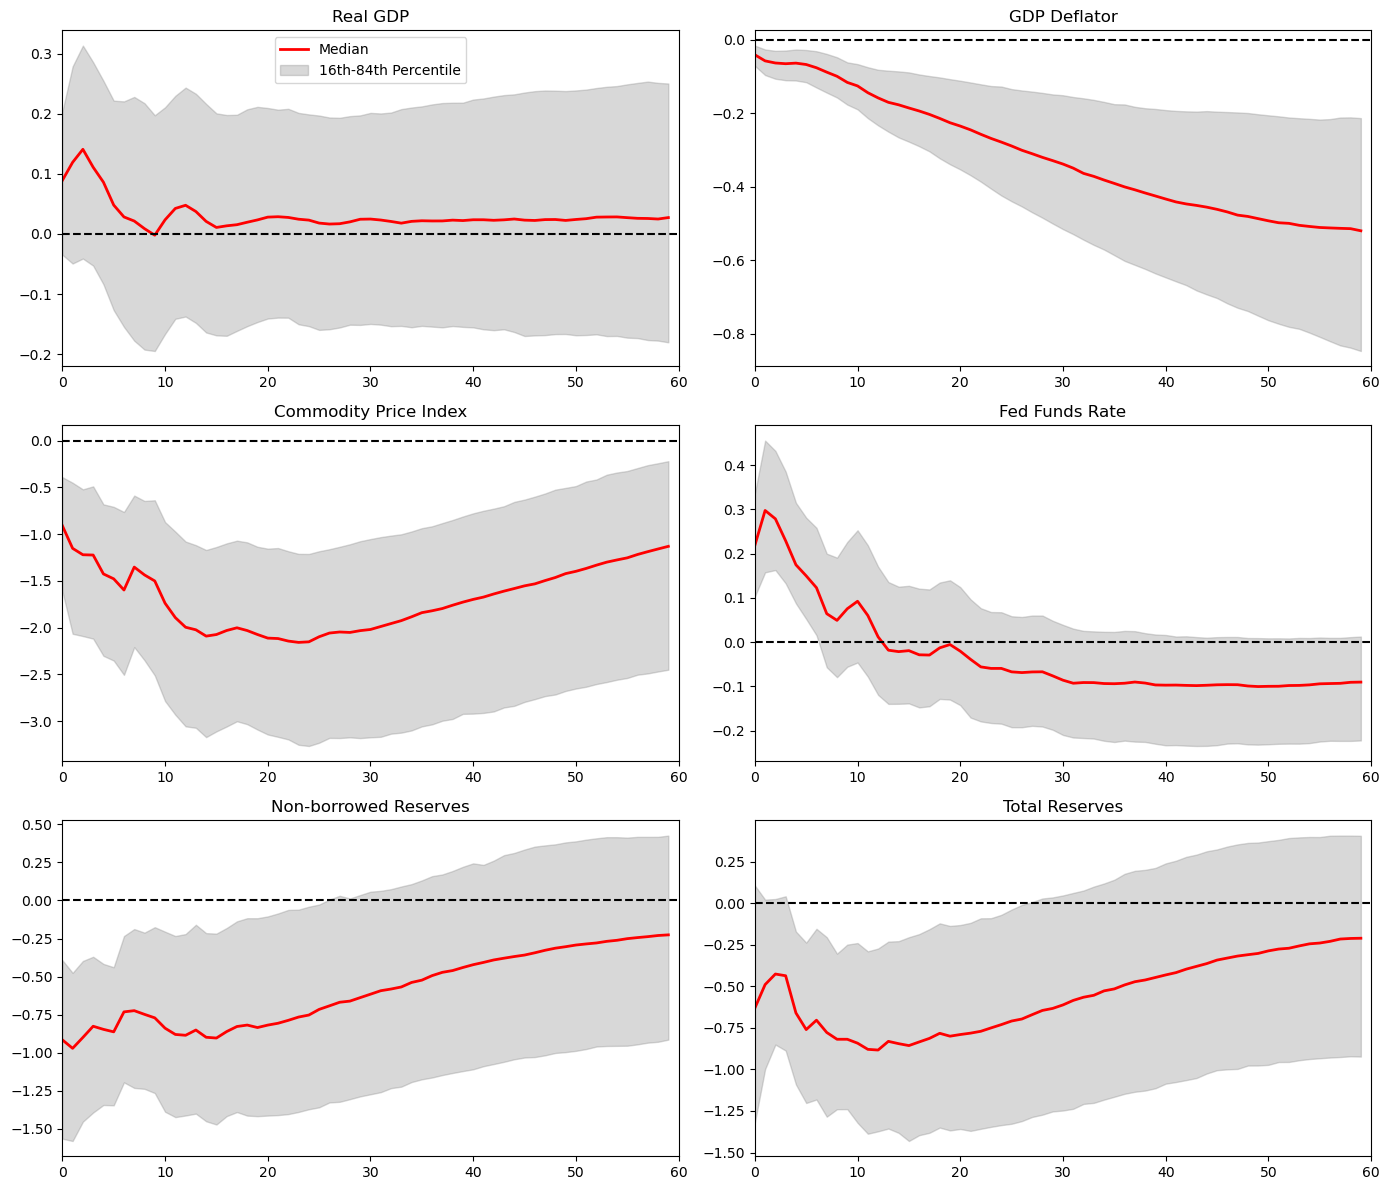

In [12]:
# ==========================================
# 6. THE FULL BAYESIAN RWZ ALGORITHM
# ==========================================
# In this section, we implement the complete Bayesian SVAR estimation by combining 
# posterior draws of the reduced-form VAR parameters with the RWZ (2010) Haar-measure rotations.
# NOTE ON METHODOLOGY: While Uhlig (2005) searches for valid impulse vectors using 
# angle parameterizations or penalty functions, RWZ (2010) proves that mapping independent 
# standard normal draws to rotation matrices via QR decomposition (the Haar measure) 
# is the ONLY way to ensure a strictly uniform, unbiased prior distribution over the 
# space of all possible structural identification schemes.
print("Starting Bayesian RWZ algorithm. Targeting 1000 valid structural IRFs...")

# These three lines set up the parameters for the Bayesian RWZ algorithm. We are about to make 1000 draws from the posterior distribution of the VAR parameters, 
# and for each draw, we will test 500 random orthogonal matrices (Q) to see if they satisfy the sign restrictions. 
# The accepted IRFs will be stored in a list for later analysis and plotting.
target_draws = 1000
batch_size = 500  # Q matrices to test per posterior draw
accepted_irfs = []

# Pre-calculate the Cholesky decomposition of inv(X'X) for the Normal draws
# This is where we compute the Cholesky factor of the inverse of the X'X matrix, which is used in the Bayesian posterior draws of the VAR coefficients.
inv_XX_chol = np.linalg.cholesky(inv_XX)

# Initialize JAX PRNG key
key = random.PRNGKey(99)

# This is the same cycle as we used in Uhlig's (2005) implementation.
while len(accepted_irfs) < target_draws:
    # 1. Draw Sigma from Inverse Wishart
    Sigma_draw = invwishart.rvs(df = df_residuals, scale = U.T @ U)
    Sigma_chol = np.linalg.cholesky(Sigma_draw)
    
    # 2. Draw B from Matrix Normal: B_draw = B_ols + chol(inv(X'X)) * Z * chol(Sigma)'
    # Z is a matrix of standard normal variables
    Z = np.random.randn(m * p + 1, m)
    B_draw = B_ols + inv_XX_chol @ Z @ Sigma_chol.T
    
    # 3. Compute base IRFs for this specific posterior draw
    base_irf = get_base_irfs(B_draw, Sigma_draw, m, p, horizon)
    base_irf_jnp = jnp.array(base_irf)
    
    # 4. Generate a batch of Q matrices using our JAX engine
    key, subkey = random.split(key)
    keys = random.split(subkey, batch_size)
    Q_batch = vmap_generate_Q(keys, n_vars)
    
    # 5. Apply the Q matrices to the base IRF (Einstein summation)
    struct_irfs = jnp.einsum('hvs,qsk->qhvk', base_irf_jnp, Q_batch)
    
    # 6. Apply Sign Restrictions mask (Monetary Policy shock)
    # GDPDEF <= 0, CPRINDEX <= 0, FEDFUNDS >= 0, BOGNONBR <= 0 for the first 6 months
    cond_prices    = struct_irfs[:, :irs, 1, :] <= 0
    cond_commodity = struct_irfs[:, :irs, 2, :] <= 0
    cond_fedfunds  = struct_irfs[:, :irs, 3, :] >= 0
    cond_nbr       = struct_irfs[:, :irs, 4, :] <= 0
    
    # Checking if all conditions are satisfied for each shock column across the restriction horizon
    combined_cond = cond_prices & cond_commodity & cond_fedfunds & cond_nbr
    valid_shocks_across_horizon = jnp.all(combined_cond, axis=1)
    
    # Get the indices of valid rotations
    valid_indices = jnp.where(valid_shocks_across_horizon)
    
    # If we found at least one valid Q in the batch, take the FIRST one to avoid over-weighting
    # This is a conservative approach to ensure that we do not bias our sample of accepted IRFs by taking multiple valid shocks from the same posterior draw.
    if len(valid_indices[0]) > 0:
        first_valid_draw_idx = valid_indices[0][0]
        first_valid_shock_idx = valid_indices[1][0]
        
        # Extract the IRF of the identified Monetary Policy shock
        valid_irf_full = struct_irfs[first_valid_draw_idx]
        identified_shock_irf = valid_irf_full[:, :, first_valid_shock_idx]
        
        accepted_irfs.append(np.array(identified_shock_irf)) # Store as numpy array for plotting later
        
        if len(accepted_irfs) % 100 == 0:
            print(f"Accepted {len(accepted_irfs)} / {target_draws} draws...")

accepted_irfs = np.array(accepted_irfs)
print("Done! We have successfully harvested 1000 Bayesian structural IRFs using RWZ (2010).")

# ==========================================
# 7. PLOTTING THE RESULTS (16th, 50th, 84th Percentiles)
# ==========================================
# We calculate the percentiles across our 1000 accepted IRFs
perc_16 = np.percentile(accepted_irfs, 16, axis=0)
perc_50 = np.percentile(accepted_irfs, 50, axis=0)
perc_84 = np.percentile(accepted_irfs, 84, axis=0)

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

# We only plot the 6 variables Uhlig focuses on
variable_names = ['Real GDP', 'GDP Deflator', 'Commodity Price Index', 
                  'Fed Funds Rate', 'Non-borrowed Reserves', 'Total Reserves']

for i in range(6):
    axes[i].plot(perc_50[:, i], color='red', linewidth=2, label='Median')
    axes[i].fill_between(range(horizon), perc_16[:, i], perc_84[:, i], color='grey', alpha=0.3, label='16th-84th Percentile')
    axes[i].axhline(0, color='black', linestyle='--')
    axes[i].set_title(variable_names[i])
    axes[i].set_xlim([0, horizon])
    if i == 0:
        axes[i].legend()

plt.tight_layout()
plt.savefig('RWZ_Bayesian_IRFs.jpg', dpi=300)
plt.show()